In [28]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# to make plot look cleaner
sns.set()


In [27]:
# load data
df = pd.read_csv(r"C:\Users\r8087\Downloads\archive (2)\Digital_Payment_Fraud_Detection_Dataset.csv")


In [29]:
# Preview data
df.head()

,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,T1,U3756,18758.28,Transfer,UPI,Web,Hyderabad,895,14,1,25535.84,0,0.718,4,0
1,T2,U7899,47538.18,Payment,Wallet,iOS,Hyderabad,918,21,0,3955.85,0,0.525,9,0
2,T3,U1765,36613.10,Payment,Card,Android,Chennai,1506,8,4,22727.71,0,0.985,9,0
3,T4,U8850,29952.99,Payment,Wallet,iOS,Chennai,800,1,3,18095.89,0,0.797,2,0
4,T5,U9049,7843.13,Payment,UPI,Web,Delhi,301,4,1,9317.49,1,0.468,1,0


In [30]:
# number of row and column
df.shape


(7500, 15)

In [31]:
# viewing the data types of columns
df.dtypes

transaction_id               object
user_id                      object
transaction_amount          float64
transaction_type             object
payment_mode                 object
device_type                  object
device_location              object
account_age_days              int64
transaction_hour              int64
previous_failed_attempts      int64
avg_transaction_amount      float64
is_international              int64
ip_risk_score               float64
login_attempts_last_24h       int64
fraud_label                   int64
dtype: object

In [32]:
df.isnull().sum()


transaction_id              0
user_id                     0
transaction_amount          0
transaction_type            0
payment_mode                0
device_type                 0
device_location             0
account_age_days            0
transaction_hour            0
previous_failed_attempts    0
avg_transaction_amount      0
is_international            0
ip_risk_score               0
login_attempts_last_24h     0
fraud_label                 0
dtype: int64

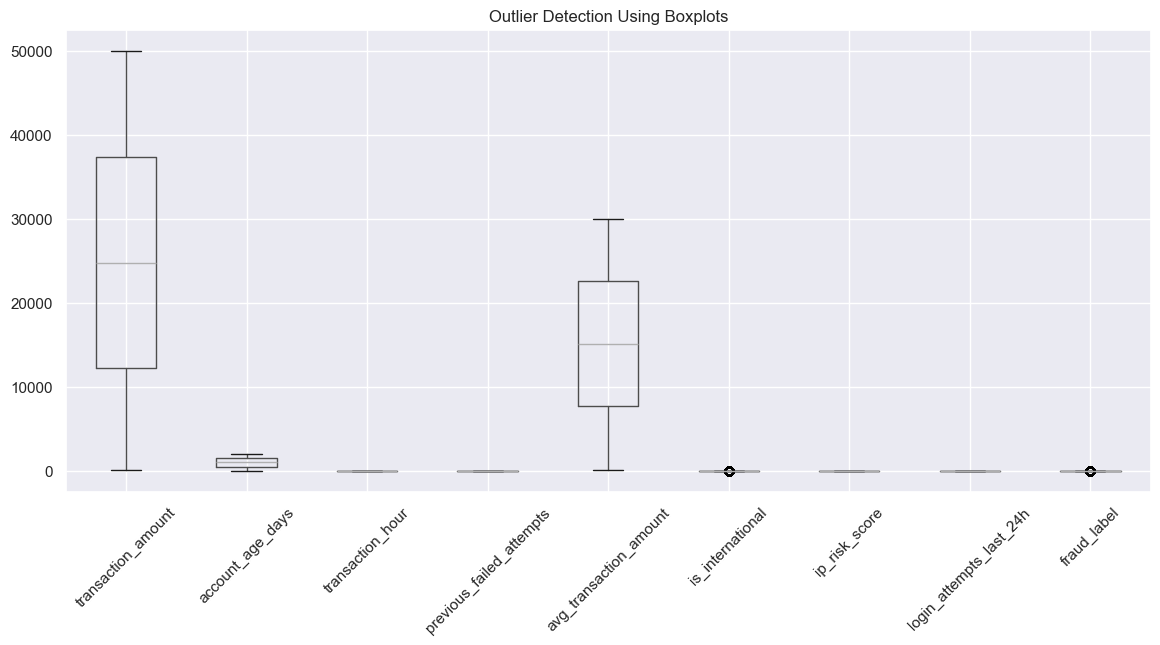

In [33]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14,6))
df[numerical_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Outlier Detection Using Boxplots")
plt.show()


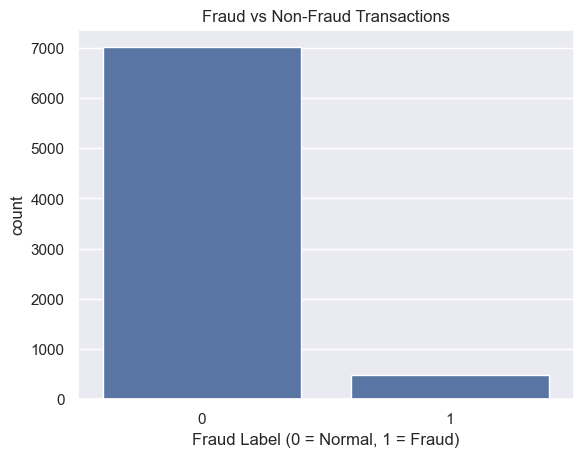

In [37]:
sns.countplot(x="fraud_label", data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Label (0 = Normal, 1 = Fraud)")
plt.show()


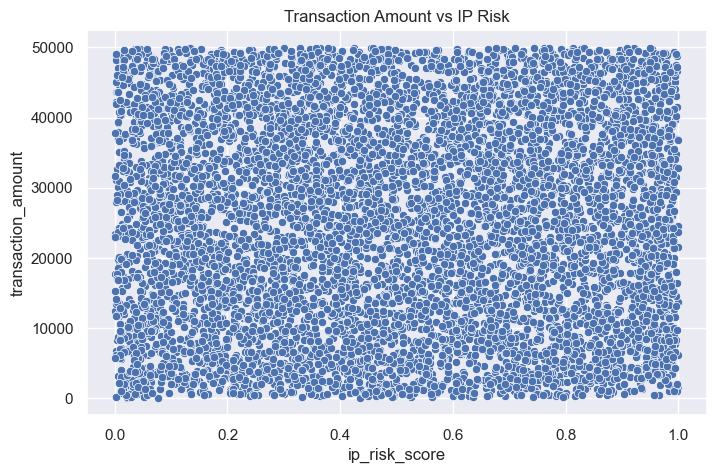

In [44]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='ip_risk_score', y='transaction_amount', data=df)
plt.title("Transaction Amount vs IP Risk")
plt.show()


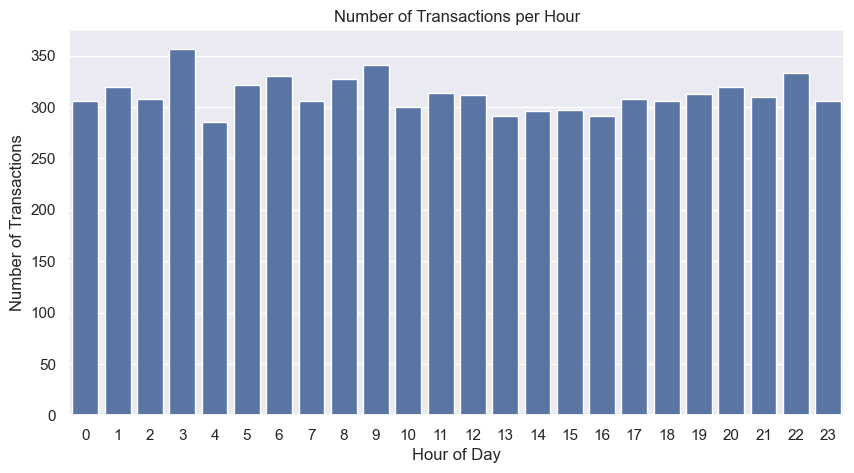

In [46]:
plt.figure(figsize=(10,5))
sns.countplot(x="transaction_hour", data=df)
plt.title("Number of Transactions per Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.show()


Even if the total number of transactions is low, a high fraud rate indicates elevated risk during specific hours

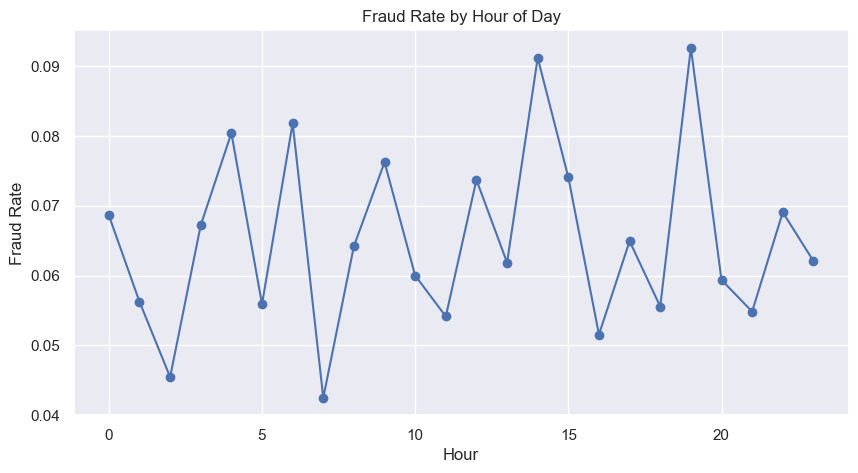

In [49]:
fraud_rate = df.groupby("transaction_hour")["fraud_label"].mean()

plt.figure(figsize=(10,5))
fraud_rate.plot(marker="o")
plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")
plt.show()



Higher average IP risk scores during certain hours suggest increased security threats at those times

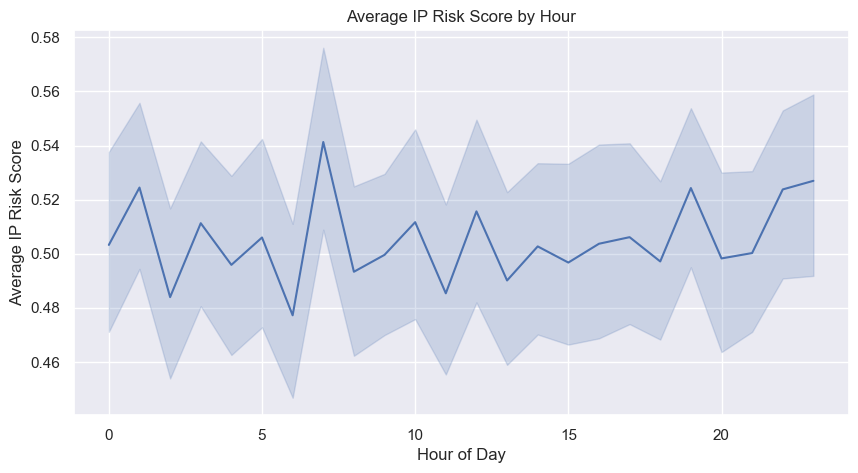

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(
    x="transaction_hour",
    y="ip_risk_score",
    data=df,
    estimator="mean"
)
plt.title("Average IP Risk Score by Hour")
plt.xlabel("Hour")
plt.ylabel("Average IP Risk Score")
plt.show()


Spikes in login attempts during unusual hours may indicate brute-force or credential-stuffing attacks

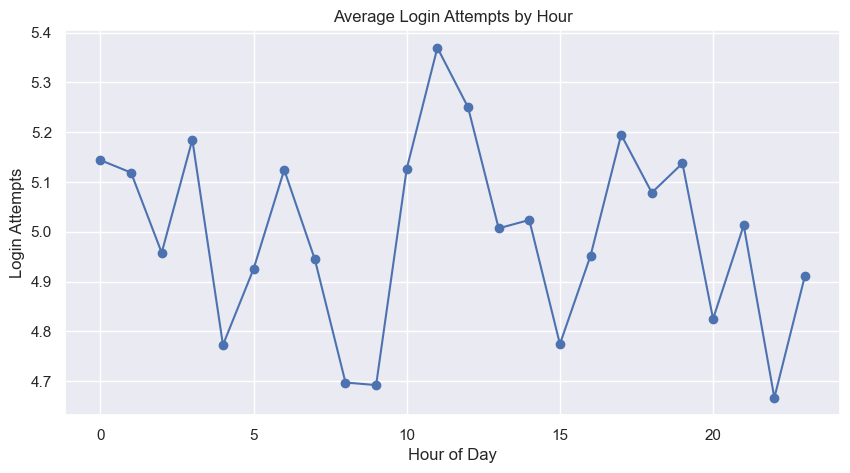

In [ ]:
login_time = df.groupby("transaction_hour")["login_attempts_last_24h"].mean()

plt.figure(figsize=(10,5))
plt.plot(login_time, marker="o")
plt.title("Average Login Attempts by Hour")
plt.xlabel("Hour")
plt.ylabel("Login Attempts")
plt.show()


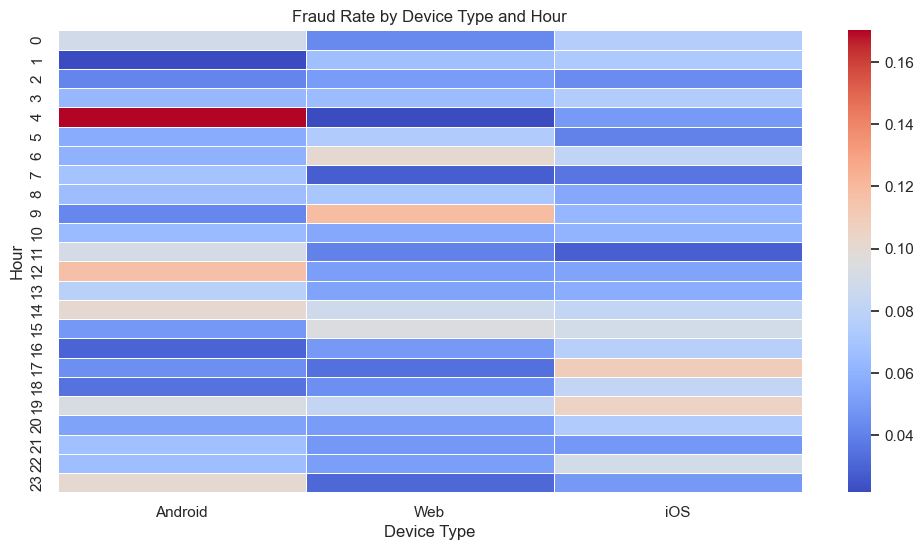

In [55]:
device_hour_heat = pd.crosstab(
    df["transaction_hour"],
    df["device_type"],
    values=df["fraud_label"],
    aggfunc="mean"
)

plt.figure(figsize=(12,6))
sns.heatmap(
    device_hour_heat,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Fraud Rate by Device Type and Hour")
plt.xlabel("Device Type")
plt.ylabel("Hour")
plt.show()


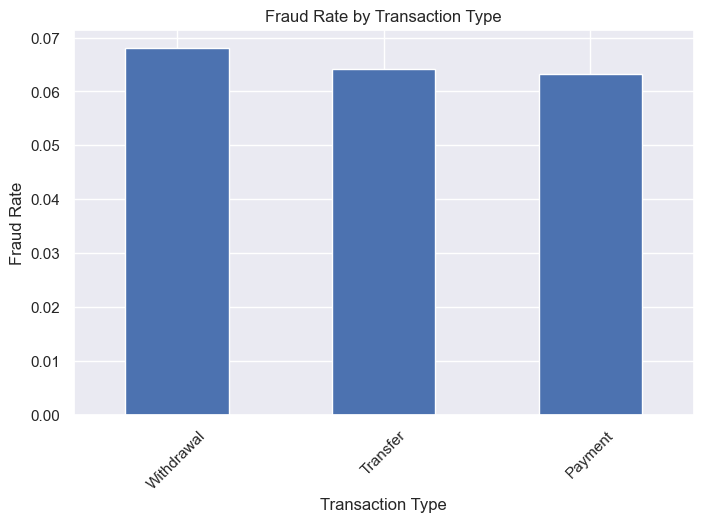

In [57]:
fraud_by_type = df.groupby("transaction_type")["fraud_label"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
fraud_by_type.plot(kind="bar")
plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.show()
